Imports

In [40]:
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
from sentence_transformers import SentenceTransformer

Extract Questions

In [41]:
cq_path = "competency_questions_all_documents.txt"

with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()

# Extract all questions from the file
questions = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.|\Z)', content, re.DOTALL)


Clustering and Plotting Function

In [42]:
def cluster_and_plot_cq(distances, model, method='ward'):
    """
    Plot a dendrogram based on the given distance matrix.
    """
    # Perform hierarchical clustering
    Z = linkage(distances, method=method)

    # Create a dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(Z, labels=questions, leaf_rotation=90)
    plt.title(f"Dendrogram of Competency Questions with {model} Vectorization")
    plt.xlabel("Questions")
    plt.ylabel("Distance")
    plt.show()


TF-IDF-Vektorisierung

/var/folders/y4/v0ln4tnn1sv81k3ph6l_gn400000gn/T/ipykernel_50044/1562976203.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distances, method=method)


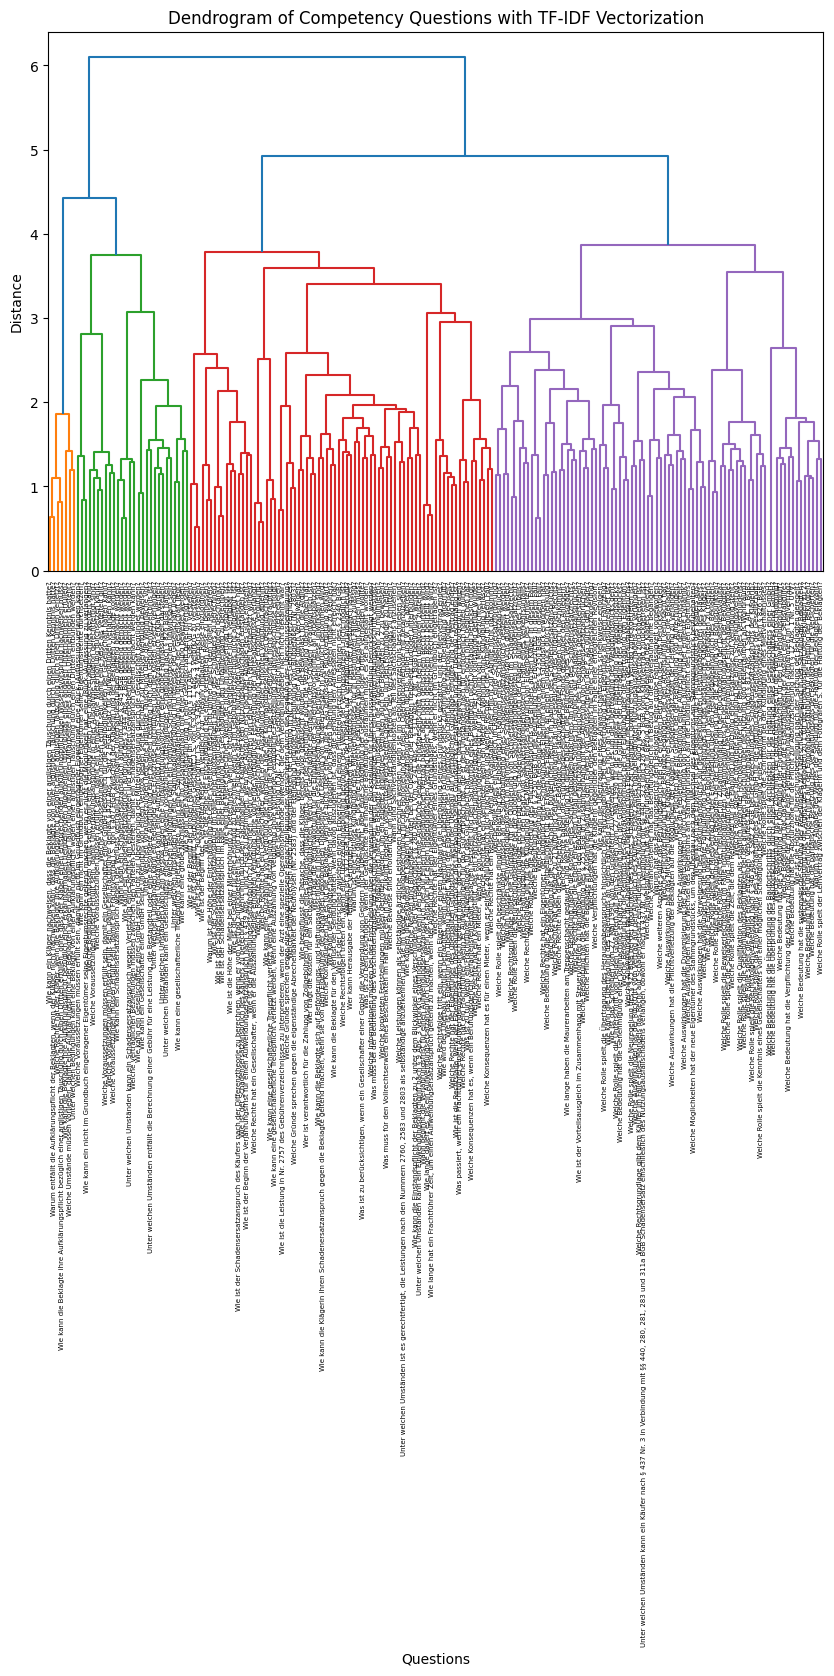

In [43]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(questions)

distances = pdist(X.toarray(), metric="cosine")

cluster_and_plot_cq(squareform(distances), "TF-IDF", method='ward')

Sentence Embedding Vertorisierung

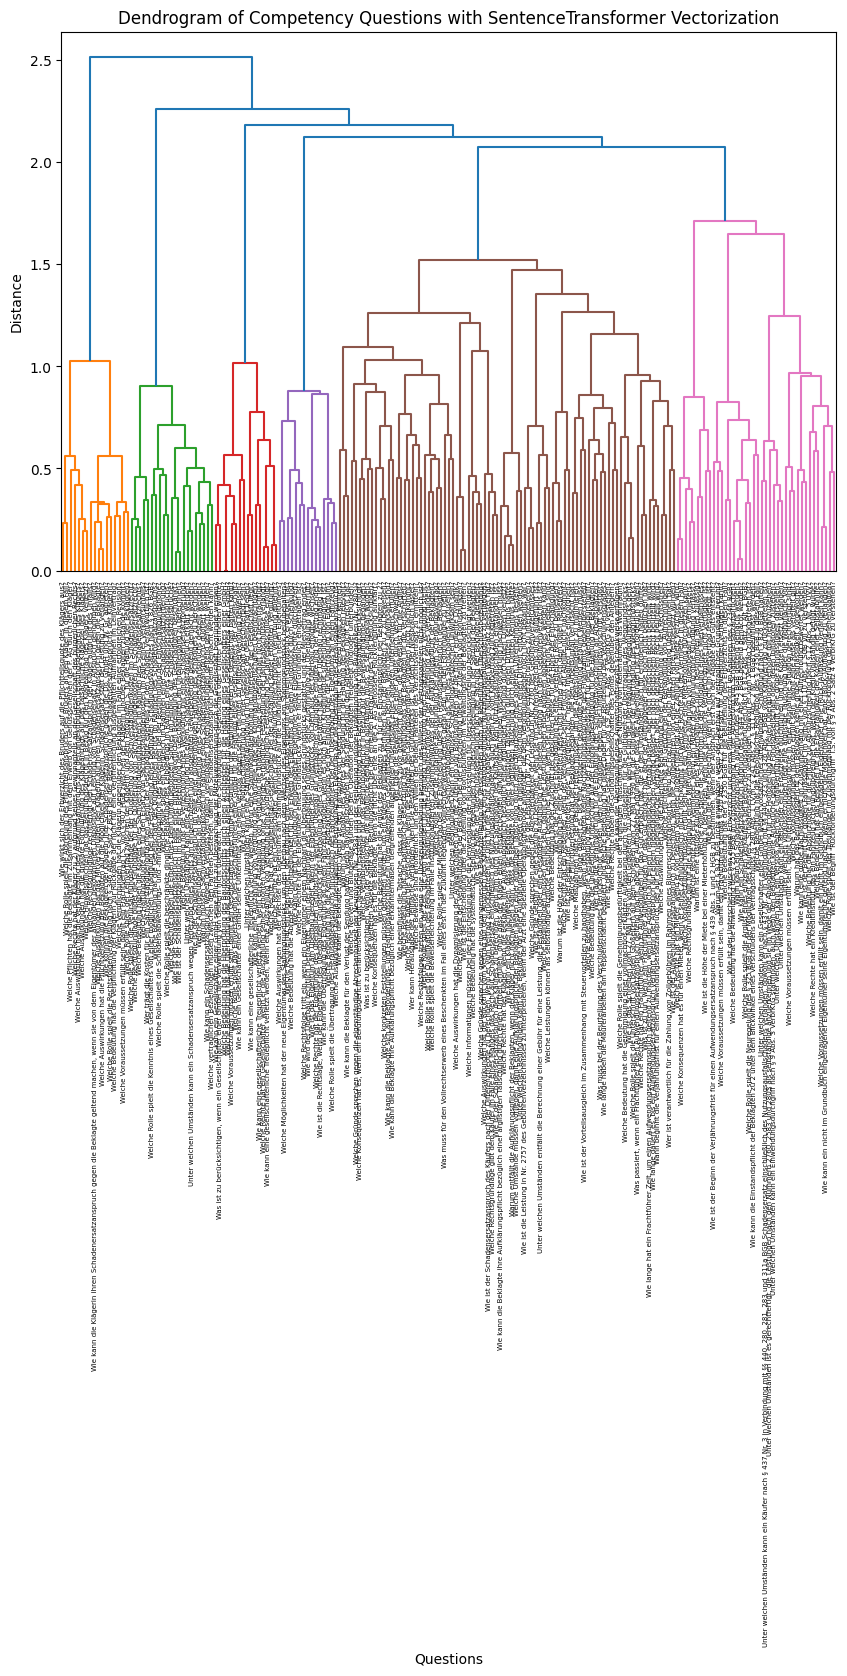

In [44]:
model = SentenceTransformer('all-MiniLM-L6-v2')  # You can choose other models from sentence-transformers

# Generate embeddings for all questions
embeddings = model.encode(questions)

# Calculate pairwise cosine distances
distances = pdist(embeddings, metric="cosine")

cluster_and_plot_cq(distances, "SentenceTransformer", method='ward')


Vergleich der Cluster

In [45]:
## Cluster-Vergleich mit festgelegten Clustern (n_clusters=5)
# Vergleich der Clusterqualität: TF-IDF vs. Sentence Embeddings
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# TF-IDF Silhouette Score
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(questions)
dist_tfidf = pdist(X_tfidf.toarray(), metric="cosine")
X_tfidf_dense = squareform(dist_tfidf)

clustering_tfidf = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=5)
labels_tfidf = clustering_tfidf.fit_predict(X_tfidf_dense)
score_tfidf = silhouette_score(X_tfidf_dense, labels_tfidf, metric="precomputed")

# Sentence Embeddings Silhouette Score
from scipy.spatial.distance import pdist, squareform
X_emb_dense = squareform(pdist(embeddings, metric="cosine"))

clustering_emb = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=5)
labels_emb = clustering_emb.fit_predict(X_emb_dense)
score_emb = silhouette_score(X_emb_dense, labels_emb, metric="precomputed")

# Ergebnisse ausgeben
print(f"📊 Silhouette Score (TF-IDF): {score_tfidf:.4f}")
print(f"📊 Silhouette Score (Sentence Embeddings): {score_emb:.4f}")

📊 Silhouette Score (TF-IDF): 0.0214
📊 Silhouette Score (Sentence Embeddings): 0.0338


In [46]:
## Cluster-Vergleich mit variablen/besten Clustern
# Vergleich der Clusterqualität: TF-IDF vs. Sentence Embeddings

from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

def find_best_n_clusters(distance_matrix, label, max_k=10):
    best_score = -1
    best_k = 2
    best_labels = None

    for k in range(2, max_k + 1):
        clustering = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
        labels = clustering.fit_predict(distance_matrix)
        score = silhouette_score(distance_matrix, labels, metric="precomputed")

        print(f"{label} | n_clusters={k} → Silhouette Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_k, best_score, best_labels

# TF-IDF
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(questions)
dist_tfidf = squareform(pdist(X_tfidf.toarray(), metric="cosine"))

best_k_tfidf, score_tfidf, labels_tfidf = find_best_n_clusters(dist_tfidf, "TF-IDF")

# Sentence Embeddings
dist_emb = squareform(pdist(embeddings, metric="cosine"))
best_k_emb, score_emb, labels_emb = find_best_n_clusters(dist_emb, "Embeddings")

print(f"\n✅ Best TF-IDF clustering: k={best_k_tfidf} | Silhouette Score: {score_tfidf:.4f}")
print(f"✅ Best Embedding clustering: k={best_k_emb} | Silhouette Score: {score_emb:.4f}")

TF-IDF | n_clusters=2 → Silhouette Score: 0.0327
TF-IDF | n_clusters=3 → Silhouette Score: 0.0243
TF-IDF | n_clusters=4 → Silhouette Score: 0.0208
TF-IDF | n_clusters=5 → Silhouette Score: 0.0214
TF-IDF | n_clusters=6 → Silhouette Score: 0.0301
TF-IDF | n_clusters=7 → Silhouette Score: 0.0303
TF-IDF | n_clusters=8 → Silhouette Score: 0.0305
TF-IDF | n_clusters=9 → Silhouette Score: 0.0378
TF-IDF | n_clusters=10 → Silhouette Score: 0.0428
Embeddings | n_clusters=2 → Silhouette Score: 0.0794
Embeddings | n_clusters=3 → Silhouette Score: 0.0424
Embeddings | n_clusters=4 → Silhouette Score: 0.0295
Embeddings | n_clusters=5 → Silhouette Score: 0.0338
Embeddings | n_clusters=6 → Silhouette Score: 0.0313
Embeddings | n_clusters=7 → Silhouette Score: 0.0665
Embeddings | n_clusters=8 → Silhouette Score: 0.0639
Embeddings | n_clusters=9 → Silhouette Score: 0.0695
Embeddings | n_clusters=10 → Silhouette Score: 0.0920

✅ Best TF-IDF clustering: k=10 | Silhouette Score: 0.0428
✅ Best Embedding clus

In [47]:
## Cluster-Vergleich mit variablen/besten Clustern und zusätzlichen Metriken
# Vergleich der Clusterqualität: TF-IDF vs. Sentence Embeddings

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering

# Vergleich der Clusterqualität
X_tfidf = vectorizer.fit_transform(questions)
dist_tfidf = pdist(X_tfidf.toarray(), metric="cosine")
X_tfidf_dense = squareform(dist_tfidf)

X_emb_dense = squareform(pdist(embeddings, metric="cosine"))

# Beste Clusteranzahl pro Cluster-Metrik finden und ausgeben/vergleichen
def find_best_n_clusters(distance_matrix, label, data_matrix, max_k=10):
    best_score = -1
    best_k = 2
    best_labels = None

    for k in range(2, max_k + 1):
        clustering = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
        labels = clustering.fit_predict(distance_matrix)
        score = silhouette_score(distance_matrix, labels, metric="precomputed")
        dbs = davies_bouldin_score(data_matrix, labels)
        chs = calinski_harabasz_score(data_matrix, labels)

        print(f"{label} | k={k} → Silhouette: {score:.4f} | DB: {dbs:.4f} | CH: {chs:.2f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_k, best_score, best_labels

best_k_tfidf, score_tfidf, labels_tfidf = find_best_n_clusters(X_tfidf_dense, "TF-IDF", X_tfidf.toarray())
best_k_emb, score_emb, labels_emb = find_best_n_clusters(X_emb_dense, "Embeddings", embeddings)

print(f"\n✅ Best TF-IDF clustering: k={best_k_tfidf} | Silhouette: {score_tfidf:.4f}")
print(f"✅ Best Embedding clustering: k={best_k_emb} | Silhouette: {score_emb:.4f}")


TF-IDF | k=2 → Silhouette: 0.0327 | DB: 5.8436 | CH: 3.94
TF-IDF | k=3 → Silhouette: 0.0243 | DB: 4.7585 | CH: 2.64
TF-IDF | k=4 → Silhouette: 0.0208 | DB: 4.4234 | CH: 2.32
TF-IDF | k=5 → Silhouette: 0.0214 | DB: 4.3046 | CH: 2.40
TF-IDF | k=6 → Silhouette: 0.0301 | DB: 4.4602 | CH: 2.58
TF-IDF | k=7 → Silhouette: 0.0303 | DB: 4.2224 | CH: 2.45
TF-IDF | k=8 → Silhouette: 0.0305 | DB: 4.1101 | CH: 2.35
TF-IDF | k=9 → Silhouette: 0.0378 | DB: 3.9323 | CH: 2.45
TF-IDF | k=10 → Silhouette: 0.0428 | DB: 3.9345 | CH: 2.50
Embeddings | k=2 → Silhouette: 0.0794 | DB: 2.1336 | CH: 2.50
Embeddings | k=3 → Silhouette: 0.0424 | DB: 1.3211 | CH: 1.98
Embeddings | k=4 → Silhouette: 0.0295 | DB: 1.6099 | CH: 2.02
Embeddings | k=5 → Silhouette: 0.0338 | DB: 1.8845 | CH: 2.65
Embeddings | k=6 → Silhouette: 0.0313 | DB: 1.9635 | CH: 2.68
Embeddings | k=7 → Silhouette: 0.0665 | DB: 2.1412 | CH: 3.93
Embeddings | k=8 → Silhouette: 0.0639 | DB: 2.1058 | CH: 3.60
Embeddings | k=9 → Silhouette: 0.0695 | DB:

In [48]:
"""
## Clustering Metrics – Interpretation Help
Silhouette Score (−1 to 1):
Higher = better. Measures how well points fit in their cluster.
0.5 = strong, ~0.1 = weak, < 0 = bad.
Davies-Bouldin Score (0+):
Lower = better. Measures cluster overlap.
~1–2 is good, >3 is poor.
Calinski-Harabasz Score (0+):
Higher = better. Measures separation vs. compactness.
Best for comparing runs.
"""

"""
## Clustering Metric Interpretation of our Results
Silhouette Score (higher is better):
Embeddings: 0.0920 vs. TF-IDF: 0.0428 → Embeddings group questions more meaningfully.
Davies-Bouldin Score (lower is better):
Embeddings: ~2.1, TF-IDF: ~4.0 → TF-IDF clusters overlap more.
Calinski-Harabasz Score (higher is better):
Embeddings: 4.25, TF-IDF: 3.94 → Slightly clearer separation with embeddings.
"""

'\n## Clustering Metric Interpretation of our Results\nSilhouette Score (higher is better):\nEmbeddings: 0.0920 vs. TF-IDF: 0.0428 → Embeddings group questions more meaningfully.\nDavies-Bouldin Score (lower is better):\nEmbeddings: ~2.1, TF-IDF: ~4.0 → TF-IDF clusters overlap more.\nCalinski-Harabasz Score (higher is better):\nEmbeddings: 4.25, TF-IDF: 3.94 → Slightly clearer separation with embeddings.\n'

Visualisierung zum Cluster-Qualitäts-Vergleich: TF-IDF vs. Sentence Embeddings

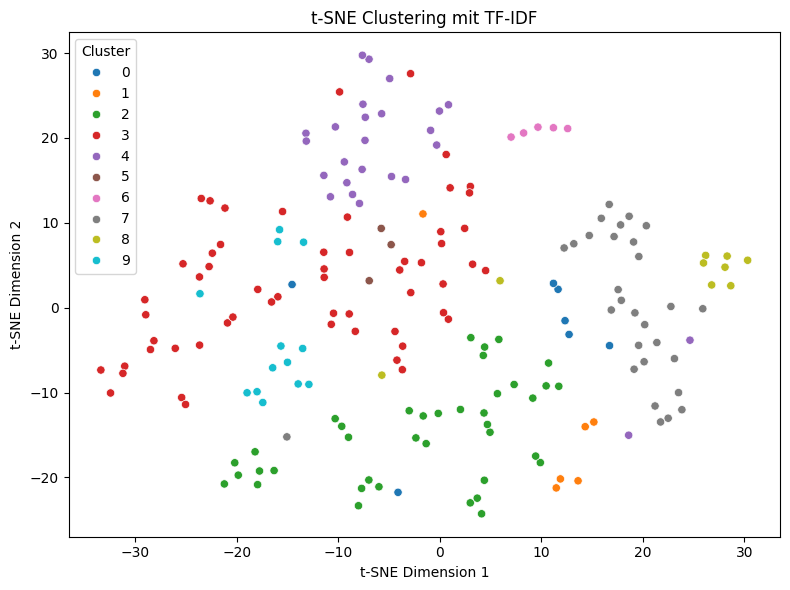

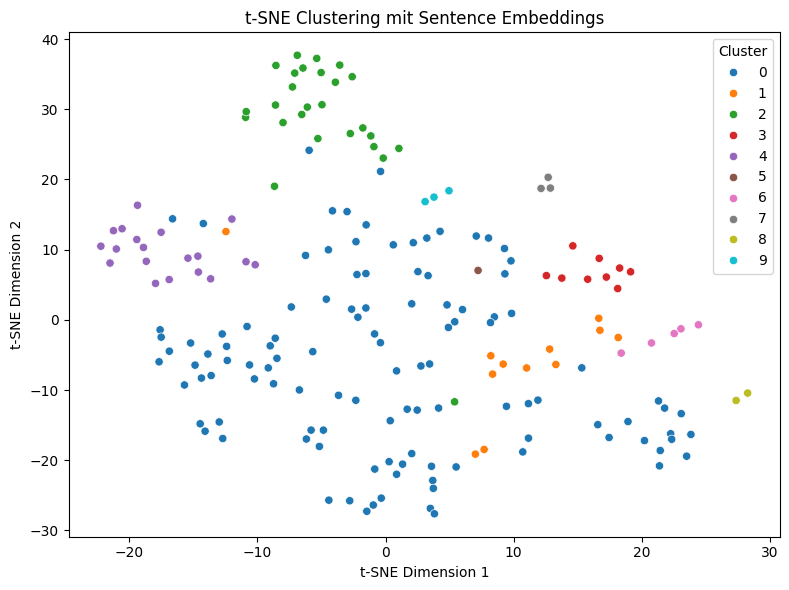

In [49]:
from sklearn.manifold import TSNE
import seaborn as sns

def plot_tsne(vectors, labels, title):
    tsne = TSNE(n_components=2, perplexity=15, random_state=42)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette='tab10')
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

# t-SNE Plots für TF-IDF und Sentence Embeddings
plot_tsne(X_tfidf.toarray(), labels_tfidf, "t-SNE Clustering mit TF-IDF")
plot_tsne(embeddings, labels_emb, "t-SNE Clustering mit Sentence Embeddings")
